# 03 · KTPO — K-Step Test-Time Policy Optimization for Long-Horizon Discovery

**Paper:** Li, Zhao, Cao, Zhang, Gonzalez, Stoica. *KTPO: K-Step Test-Time Policy Optimization for Long-Horizon Discovery.* COLM 2026 (`papers/398_KTPO_K_Step_Test_Time_Poli.pdf`).

**Code status:** the authors' repository (`github.com/DachengLi1/KTPO`) was an *empty placeholder* (0 commits) when this notebook was written, so every mechanism below is re-implemented from Algorithm 1 and Appendix D in `notebooks/ktpo/`. The Circle Packing (n=26) seed program and validity checker are OpenEvolve's example (Apache-2.0, vendored in `notebooks/vendor/openevolve_circle_packing/`), which the paper cites as its initial program.

**What this notebook tests, block by block**

| § | Building block | Paper ref | Module |
|---|---|---|---|
| 1 | Deterministic evaluator s(·) and the seed program p₀ | Sec. 3, App. C | `ktpo/evaluator.py` |
| 2 | Program pool P: uniform parent sampling, adding valid children, eviction | Alg. 1 l.1,7,11,24 | `ktpo/pool.py` |
| 3 | Improvement reward r ∈ {+1, 0, −0.5} and GRPO group advantages | eq. (1), Sec. 3.2 | `ktpo/reward.py` |
| 4 | Improvement rate β, mastery threshold schedule τ_t, rolling buffer R, eviction threshold s̄ | eq. (2), Alg. 1 l.4,17-24 | `ktpo/reward.py` |
| 5 | MultiStepRefine: k sequential revisions with structured evaluator feedback | Sec. 3.1, App. D | `ktpo/refine.py` |
| 6 | Full inference-only KTPO search loop (frozen API model) + ablations | Alg. 1, Sec. 4.3 | `ktpo/search.py` |
| 7 | Tiny real GRPO run (Train phase) on the local GPU | Sec. 3.2, App. B | `ktpo/grpo_train.py` |
| 8 | Training vs inference-only: average best-of-k per batch | Sec. 4.3, Fig. 3a | — |

LLM calls go to OpenRouter using the project's `.env` (`RCP_MODEL`). Set `NB_QUICK=1` to shrink budgets.

In [1]:
import os, sys, json, time, random
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import matplotlib.pyplot as plt
common.banner()
OUT = OUTPUT_DIR / "ktpo"; OUT.mkdir(exist_ok=True)

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

## 1 · Evaluator s(·) and seed program p₀

The paper assumes "a deterministic evaluator s(·) that assigns a scalar score to candidate programs". For Circle Packing the score is the sum of radii of a *valid* packing (26 circles inside the unit square, no overlaps); invalid packings score 0. `ktpo/evaluator.py` wraps OpenEvolve's checker in a subprocess with a timeout and turns its diagnostics into the feedback string the model sees in the next refinement step (App. D.4).

In [2]:
from ktpo.evaluator import SEED_PROGRAM, evaluate, VENDOR
print((VENDOR / "COMMIT").read_text().strip(), "(OpenEvolve commit)")
print(SEED_PROGRAM[:900] + "\n...")

411fb59c886c18704caaffb611e17cf9e7d824d2 (OpenEvolve commit)
# EVOLVE-BLOCK-START
"""Constructor-based circle packing for n=26 circles"""
import numpy as np


def construct_packing():
    """
    Construct a specific arrangement of 26 circles in a unit square
    that attempts to maximize the sum of their radii.

    Returns:
        Tuple of (centers, radii, sum_of_radii)
        centers: np.array of shape (26, 2) with (x, y) coordinates
        radii: np.array of shape (26) with radius of each circle
        sum_of_radii: Sum of all radii
    """
    # Initialize arrays for 26 circles
    n = 26
    centers = np.zeros((n, 2))

    # Place circles in a structured pattern
    # This is a simple pattern - evolution will improve this

    # First, place a large circle in the center
    centers[0] = [0.5, 0.5]

    # Place 8 circles around it in a ring
    for i in range(8):
        angle = 2 * np.pi * i / 8
        centers[i + 1] = [0.5 + 0.3 * np.c
...


In [3]:
seed_result = evaluate(SEED_PROGRAM)
seed_result

Result(score=0.9597642169962064, valid=True, feedback='this_step=0.9598 validity=True boundary_violations=0 overlaps=0', sum_radii_raw=0.9597642169962064, boundary_violations=0, overlaps=0, error=None)

The seed scores ≈0.96: OpenEvolve's initial program is a deliberately weak concentric layout (the human record is 2.634, AlphaEvolve 2.635). Two negative controls show the evaluator failing closed the way the paper's reward needs it to (invalid → score 0 plus a diagnostic):

In [4]:
broken_overlap = SEED_PROGRAM.replace("radii = compute_max_radii(centers)", "radii = compute_max_radii(centers) * 1.5  # overlaps!")
broken_crash = SEED_PROGRAM.replace("n = 26", "n = 26\n    raise IndexError('list index out of range')")
for name, src in [("overlap", broken_overlap), ("crash", broken_crash)]:
    r = evaluate(src); print(f"{name:8s} score={r.score:.4f} valid={r.valid} feedback={r.feedback}")

overlap  score=0.0000 valid=False feedback=this_step=0.0000 validity=False boundary_violations=15 overlaps=8 (raw sum_radii=1.4396, score set to 0 because the packing is invalid)
crash    score=0.0000 valid=False feedback=error=list index out of range


## 2 · Program pool P

Algorithm 1: P starts as {p₀}; parents are sampled *uniformly* from P (line 7); every intermediate refinement with positive score is added (line 11); after each iteration `P ← {p : s(p) ≥ s̄}` (line 24). The test below drives the pool with synthetic programs so the mechanics are visible without any model call.

In [5]:
from ktpo.pool import Program, ProgramPool
show_source(ProgramPool.evict)
rng = random.Random(0)
pool = ProgramPool.from_seed(SEED_PROGRAM, seed_result.score)
# synthetic children: distinct sources with scores spread between 0 and 2.4 (invalid ones have score 0)
for i, sc in enumerate([0.0, 1.2, 1.9, 0.0, 2.1, 2.4, 1.0]):
    added = pool.add(Program(f"# child {i}\n" + SEED_PROGRAM, sc, parent="seed", iteration=1, origin="child"))
    print(f"child {i} score={sc:.1f} added={added}")
print("pool scores:", pool.scores)
print("uniform sample of 5 parents:", [round(p.score, 2) for p in pool.sample(rng, 5)])
evicted = pool.evict(threshold=1.5)
print("after evict(s̄=1.5):", pool.scores, "| evicted", [round(p.score, 2) for p in evicted])

**ProgramPool.evict**

```python
    def evict(self, threshold: float, keep_best: bool = True) -> list[Program]:
        """P ← {p ∈ P : s(p) ≥ s̄}. The best program is always retained so P never empties."""
        best = self.best
        evicted = [p for p in self.programs.values() if p.score < threshold and not (keep_best and p is best)]
        for p in evicted:
            del self.programs[p.pid]
        return evicted

```

child 0 score=0.0 added=False
child 1 score=1.2 added=True
child 2 score=1.9 added=True
child 3 score=0.0 added=False
child 4 score=2.1 added=True
child 5 score=2.4 added=True
child 6 score=1.0 added=True
pool scores: [2.4, 2.1, 1.9, 1.2, 1.0, 0.9597642169962064]
uniform sample of 5 parents: [2.1, 2.1, 0.96, 1.9, 2.4]
after evict(s̄=1.5): [2.4, 2.1, 1.9] | evicted [0.96, 1.2, 1.0]


## 3 · Improvement reward and GRPO advantages

$$r_j=\begin{cases}+1 & s_j^* > s(p_i)\\ 0 & \text{valid but } s_j^*\le s(p_i)\\ -0.5 & \text{invalid}\end{cases}\qquad \hat A_j=\frac{r_j-\bar r}{\sigma_r}$$

where $s_j^*=\max_{\ell\le k} s(c_j^{(\ell)})$ is the best score across the k revision steps of child j, and advantages are normalised within one parent's group of N children.

In [6]:
from ktpo.reward import reward, grpo_advantages
show_source(reward)
cases = [("beats parent", 2.30, 2.20, True), ("valid, no gain", 2.10, 2.20, True), ("equal score", 2.20, 2.20, True), ("invalid", 0.0, 2.20, False)]
rows = [{"case": n, "s*": s, "s(parent)": p, "valid": v, "reward": reward(s, p, v)} for n, s, p, v in cases]
display(df(rows))
group = [reward(s, p, v) for _, s, p, v in cases]
print("group rewards", group, "→ advantages", [round(a, 3) for a in grpo_advantages(group)])
print("all-equal group →", grpo_advantages([0.0, 0.0, 0.0, 0.0]), "(no learning signal, as in GRPO)")

**reward**

```python
def reward(best_child_score: float, parent_score: float, valid: bool) -> float:
    """Equation (1). ``best_child_score`` is s*_j = max over the k revision steps."""
    if not valid:
        return INVALID_PENALTY
    return 1.0 if best_child_score > parent_score else 0.0

```

,case,s*,s(parent),valid,reward
0,beats parent,2.3,2.2,True,1.0
1,"valid, no gain",2.1,2.2,True,0.0
2,equal score,2.2,2.2,True,0.0
3,invalid,0.0,2.2,False,-0.5


group rewards [1.0, 0.0, 0.0, -0.5] → advantages [1.606, -0.229, -0.229, -1.147]
all-equal group → [0.0, 0.0, 0.0, 0.0] (no learning signal, as in GRPO)


## 4 · Improvement rate β, threshold schedule τ_t, rolling buffer, eviction threshold s̄

$$\beta_i=\frac1N\sum_{j=1}^N \mathbb 1[s^*_{i,j}>s(p_i)]\qquad \tau_t=\tau_0+(\tau_T-\tau_0)\,t/T\qquad \bar s=\mathrm{mean}(\mathcal R[\text{last }W])$$

A parent is *mastered* when β_i ≥ τ_t; its score enters the rolling buffer R; the eviction threshold is the mean of the last W mastered scores. Paper defaults: τ₀=0.3 → τ_T=0, W=10.

**EvictionTracker**

```python
@dataclass
class EvictionTracker:
    """Rolling buffer R of mastered-parent scores and the resulting eviction threshold s̄."""

    window: int = 10
    mastered: list[float] = field(default_factory=list)

    def record_if_mastered(self, beta: float, parent_score: float, tau_t: float) -> bool:
        if beta >= tau_t:
            self.mastered.append(parent_score)
            return True
        return False

    @property
    def threshold(self) -> float | None:
        recent = self.mastered[-self.window:]
        return statistics.fmean(recent) if recent else None

```

β examples: 0.5 0.0


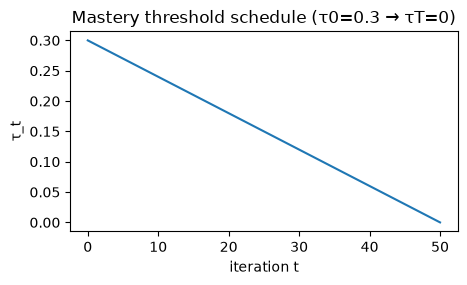

,t,τ_t,s(parent),β,mastered,R (last W),s̄
0,1,0.263,1.15,0.25,False,[],NaN
1,2,0.225,1.30,0.00,False,[],NaN
2,3,0.188,1.45,0.50,True,[1.45],1.45
3,4,0.150,1.60,0.00,False,[1.45],1.45
4,5,0.112,1.75,0.75,True,"[1.45, 1.75]",1.60
5,6,0.075,1.90,0.75,True,"[1.45, 1.75, 1.9]",1.70
6,7,0.037,2.05,0.75,True,"[1.75, 1.9, 2.05]",1.90
7,8,0.000,2.20,0.75,True,"[1.9, 2.05, 2.2]",2.05


In [7]:
from ktpo.reward import improvement_rate, mastery_threshold, EvictionTracker
show_source(EvictionTracker)
print("β examples:", improvement_rate([2.3, 2.1, 2.25, 0.0], 2.2), improvement_rate([0.0, 0.0], 2.2))
T = 50
sched = [mastery_threshold(t, T) for t in range(T + 1)]
fig, ax = plt.subplots(figsize=(5, 2.6)); ax.plot(sched); ax.set(xlabel="iteration t", ylabel="τ_t", title="Mastery threshold schedule (τ0=0.3 → τT=0)"); plt.show()

# synthetic run of the tracker: parents with rising scores, β drawn from a coin
tracker = EvictionTracker(window=3)
rng = random.Random(1)
rows = []
for t in range(1, 9):
    tau = mastery_threshold(t, 8)
    parent_score, beta = 1.0 + 0.15 * t, rng.choice([0.0, 0.25, 0.5, 0.75])
    mastered = tracker.record_if_mastered(beta, parent_score, tau)
    rows.append({"t": t, "τ_t": round(tau, 3), "s(parent)": round(parent_score, 2), "β": beta, "mastered": mastered, "R (last W)": list(map(lambda x: round(x, 2), tracker.mastered[-3:])), "s̄": None if tracker.threshold is None else round(tracker.threshold, 3)})
display(df(rows))

## 5 · MultiStepRefine (k sequential revisions with feedback) — live model calls

Appendix D gives the exact prompt scaffold: a system message, a task context, the output-format rule ("COMPLETE, SELF-CONTAINED program as a single ```python code block"), the reward rules shown to the model, and a structured feedback message between steps that carries the step counter, this step's score/validity or error, the reference score, and all scores so far. `ktpo/refine.py` reproduces these verbatim where the paper prints them.

The cell runs one k-step trajectory from the seed program with the frozen API model and prints each feedback message.

In [8]:
from ktpo import refine
print(refine.SYSTEM_MESSAGE, "\n---\n", refine.OUTPUT_FORMAT, "\n---\n", refine.REWARD_RULES)

You are an expert software developer tasked with iteratively improving a codebase. Your job is to analyze the current program and suggest improvements based on feedback from previous attempts. Focus on making targeted changes that will increase the program's performance metrics. 
---
 Output the COMPLETE, SELF-CONTAINED program as a single ```python code block. Your code block MUST include ALL imports, ALL helper functions, and the main entry-point function. Do NOT output partial snippets, diffs, or incomplete code — every code block you produce will be executed as a standalone program. 
---
 You will get multiple refinement attempts. After each attempt, you will see your score and can try again. Your reward is based on the BEST score you achieve across all attempts minus your starting score. You get PENALIZED for producing INVALID programs (syntax errors, runtime errors, or constraint violations). You get PENALIZED for producing the SAME score as your previous attempt (lazy repetition

In [9]:
K = 2 if QUICK else 4
t0 = time.time()
traj = refine.multistep_refine(SEED_PROGRAM, seed_result.score, k=K, verbose=False)
scores = []
for s in traj.steps:
    scores.append(s["result"].score)
    print(refine.feedback_message(s["step"], K, s["result"], seed_result.score, scores).split("\n\n")[0], "\n")
print(f"s* (best in trajectory) = {traj.best_score:.4f} vs parent {seed_result.score:.4f} → reward {reward(traj.best_score, seed_result.score, traj.any_valid)}  [{time.time()-t0:.0f}s]")

[Step 1/4, 3 remaining] this_step=1.1585 validity=True boundary_violations=0 overlaps=0
Reference program score: 0.9598
Your scores so far:    1.1585 (this step) 

[Step 2/4, 2 remaining] this_step=1.7305 validity=True boundary_violations=0 overlaps=0
Reference program score: 0.9598
Your scores so far:    1.1585 → 1.7305 (this step) 

[Step 3/4, 1 remaining] this_step=0.0000 error=Process timed out after 60 seconds
Reference program score: 0.9598
Your scores so far:    1.1585 1.7305 → 0.0000 (this step) 

[Step 4/4, 0 remaining] this_step=2.2726 validity=True boundary_violations=0 overlaps=0
Reference program score: 0.9598
Your scores so far:    1.1585 1.7305 0.0000 → 2.2726 (this step) 

s* (best in trajectory) = 2.2726 vs parent 0.9598 → reward 1.0  [135s]


In [10]:
best = traj.best_src
if best:
    print(best[:1500], "\n...")
    (OUT / "refine_best.py").write_text(best)

# EVOLVE-BLOCK-START
"""Constructor-based circle packing for n=26 circles - fast staggered grid"""
import numpy as np

def construct_packing():
    """
    Construct a packing of 26 circles in a unit square using a carefully
    positioned staggered grid that maximizes the sum of radii without
    requiring iterative optimization.
    """
    n = 26
    
    # Use a 5-row staggered layout: rows with 5,5,6,5,5 circles = 26 total
    # The layout is designed to maximize packing density while keeping all circles inside.
    # We'll use a uniform spacing in each row and between rows, tuned to maximize radii.
    # The spacing is chosen to be as large as possible while keeping all circles inside [0,1].
    
    # Number of rows and their counts
    row_counts = [5, 5, 6, 5, 5]
    n_rows = len(row_counts)
    
    # We'll determine positions by solving for the maximum possible uniform spacing
    # that keeps circles inside the square and non-overlapping.
    # For a hexagonal packing, the 

## 6 · Inference-only KTPO search (Algorithm 1 without the Train phase)

The full loop with the frozen API model: T iterations × B parents × N children × k steps. Every valid intermediate program joins the pool; β, τ_t, the rolling buffer and eviction run exactly as in Sec. 3.3. This mirrors the paper's *"Learning vs inference-only search"* control (Sec. 4.3) and produces the pool-size and best-score curves of Fig. 2.

In [11]:
from ktpo.search import ktpo_search
cfg = dict(T=3, B=1, N=2, k=2) if QUICK else dict(T=5, B=2, N=2, k=3)
print("config", cfg, "→", cfg["T"] * cfg["B"] * cfg["N"] * cfg["k"], "LLM calls")
pool, logs = ktpo_search(SEED_PROGRAM, seed_result.score, **cfg, use_pool=True, use_eviction=True, rng_seed=0)

config {'T': 5, 'B': 2, 'N': 2, 'k': 3} → 60 LLM calls


iter 1: τ=0.24 best=2.1083 avg_best_of_k=1.801 pool=5 evicted=0 s̄=0.9598 β=[1.0, 1.0] (118s)


iter 2: τ=0.18 best=2.3144 avg_best_of_k=2.011 pool=15 evicted=1 s̄=1.0682 β=[1.0, 1.0] (287s)


iter 3: τ=0.12 best=2.4977 avg_best_of_k=2.139 pool=20 evicted=3 s̄=1.3408 β=[1.0, 1.0] (151s)


iter 4: τ=0.06 best=2.4977 avg_best_of_k=2.014 pool=25 evicted=3 s̄=1.5145 β=[0.5, 0.5] (224s)


iter 5: τ=0.00 best=2.5399 avg_best_of_k=1.529 pool=31 evicted=2 s̄=1.602 β=[1.0, 0.0] (237s)


,iteration,size,best,mean,evicted,threshold
0,1,5,2.108257,1.521364,0,0.959764
1,2,15,2.314418,1.734618,1,1.068162
2,3,20,2.497653,1.886045,3,1.340820
3,4,25,2.497653,1.982515,3,1.514461
4,5,31,2.539916,2.005897,2,1.601968


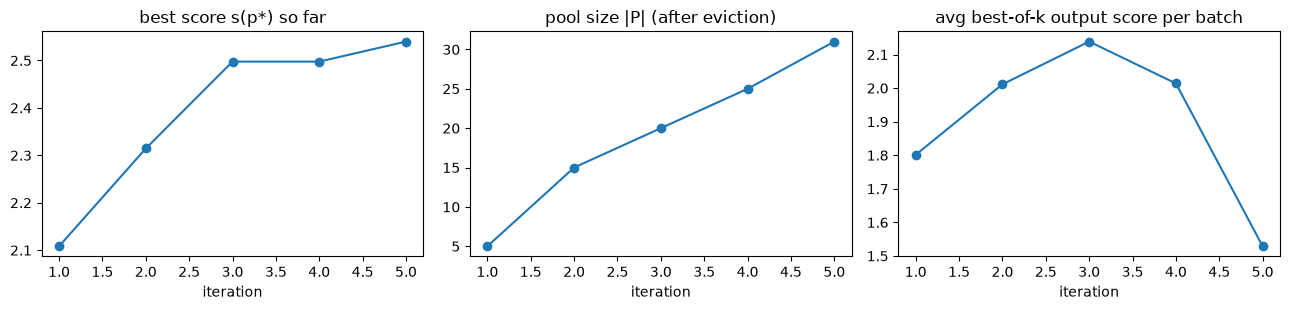

,t,τ_t,parent scores,β,mastered,rewards,s̄,evicted
0,1,0.24,"[0.96, 0.96]","[1.0, 1.0]","[True, True]","[[1.0, 1.0], [1.0, 1.0]]",0.960,0
1,2,0.18,"[0.96, 1.393]","[1.0, 1.0]","[True, True]","[[1.0, 1.0], [1.0, 1.0]]",1.068,1
2,3,0.12,"[2.014, 1.758]","[1.0, 1.0]","[True, True]","[[1.0, 1.0], [1.0, 1.0]]",1.341,3
3,4,0.06,"[2.314, 1.756]","[0.5, 0.5]","[True, True]","[[1.0, 0.0], [1.0, 0.0]]",1.514,3
4,5,0.00,"[1.824, 2.08]","[1.0, 0.0]","[True, True]","[[1.0, 1.0], [-0.5, 0.0]]",1.602,2


best program score: 2.5399


3974

In [12]:
hist = df(pool.history); display(hist)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(hist["iteration"], hist["best"], marker="o"); axes[0].set(title="best score s(p*) so far", xlabel="iteration")
axes[1].plot(hist["iteration"], hist["size"], marker="o"); axes[1].set(title="pool size |P| (after eviction)", xlabel="iteration")
axes[2].plot([l.t for l in logs], [l.avg_best_of_k for l in logs], marker="o"); axes[2].set(title="avg best-of-k output score per batch", xlabel="iteration")
plt.tight_layout(); plt.show()
rows = [{"t": l.t, "τ_t": round(l.tau_t, 2), "parent scores": [round(p["score"], 3) for p in l.parents], "β": [p["beta"] for p in l.parents], "mastered": [p["mastered"] for p in l.parents], "rewards": [p["rewards"] for p in l.parents], "s̄": None if l.threshold is None else round(l.threshold, 3), "evicted": l.evicted} for l in logs]
display(df(rows))
print("best program score:", round(pool.best.score, 4))
(OUT / "search_pool.jsonl").write_text("".join(json.dumps({"src": p.src, "score": p.score}) + "\n" for p in pool.programs.values()))
(OUT / "search_logs.json").write_text(json.dumps([l.__dict__ for l in logs], indent=1, default=str))

### 6b · Ablations (Sec. 4.3): no pool / no eviction

Set `RUN_ABLATIONS = True` to rerun the same budget with `use_pool=False` (always refine p₀, the paper's "Pool vs no pool") and `use_eviction=False` (pool grows unboundedly, "Improvement-rate eviction"). At this miniature budget the differences are noisy; the point is that each switch isolates one mechanism.

In [13]:
RUN_ABLATIONS = os.environ.get("NB_ABLATIONS", "0") == "1"
if RUN_ABLATIONS:
    results = {"full": hist}
    for name, kw in {"no_pool": dict(use_pool=False), "no_eviction": dict(use_eviction=False)}.items():
        p_, l_ = ktpo_search(SEED_PROGRAM, seed_result.score, **cfg, rng_seed=0, verbose=False, **{**dict(use_pool=True, use_eviction=True), **kw})
        results[name] = df(p_.history)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    for name, h in results.items():
        axes[0].plot(h["iteration"], h["best"], marker="o", label=name); axes[1].plot(h["iteration"], h["size"], marker="o", label=name)
    axes[0].set(title="best score"); axes[1].set(title="pool size"); axes[0].legend(); plt.tight_layout(); plt.show()
else:
    print("skipped (set NB_ABLATIONS=1 to run the no-pool / no-eviction variants)")

skipped (set NB_ABLATIONS=1 to run the no-pool / no-eviction variants)


## 7 · Tiny GRPO run (the Train phase) on the local GPU

The paper trains Qwen3-4B / Qwen3.5-9B on 8×H100 with B=16 parents × N=16 children × k=8 steps. Appendix B shows the mechanism also works for a 1.5B model with k=1. Here `ktpo/grpo_train.py` runs TRL's `GRPOTrainer` with **Qwen2.5-Coder-1.5B-Instruct + LoRA** on the RTX A4500: one parent group of N children per optimizer step, the improvement reward of eq. (1) computed by the real evaluator, DAPO clip-higher ε∈[0.2,0.28], no KL term. Parents are sampled uniformly from the pool produced in §6 (so the prompts are the same App. D scaffold).

A probe before training showed the untuned 1.5B model emits a *valid* packing only ~15–25% of the time (most completions crash), so the reward is mostly −0.5 with some 0s: exactly the regime where the improvement reward teaches validity first. The prompt carries the paper's App. D scaffold plus a short engineering hint for the small model (`SMALL_MODEL_HINT`, disable with `--no-hint`); the evaluator re-attaches OpenEvolve's fixed `run_packing()` entry point if a rewrite dropped it (the benchmark defines that part as non-evolved).

Expected outcome: the pipeline runs end to end and the valid-rate / mean-reward curves move over ~20 steps. It will **not** approach 2.63 — that needs the paper's compute.

In [14]:
import subprocess, shutil
STEPS = 4 if QUICK else 20
GEN = 4 if QUICK else 8
grpo_out = OUT / "grpo"
# Parents: the seed program p0 by default (Appendix B setting: training vs inference-only from the same
# initial program). Set GRPO_FROM_POOL=1 to sample parents from the §6 search pool instead (Alg. 1 proper);
# with parents already at ~2.3 the 1.5B model cannot earn +1, so the seed gives a more informative curve.
pool_args = ["--pool", str(OUT / "search_pool.jsonl")] if os.environ.get("GRPO_FROM_POOL", "0") == "1" else []
cmd = [sys.executable, "-m", "ktpo.grpo_train", "--steps", str(STEPS), "--num-generations", str(GEN), "--max-completion-length", "1536", *pool_args, "--out", str(grpo_out)]
print(" ".join(cmd))
t0 = time.time()
proc = subprocess.run(cmd, capture_output=True, text=True)
log_lines = [l for l in (proc.stdout + "\n" + proc.stderr).splitlines() if l.startswith("[reward]") or "done in" in l or l.startswith("pool:")]
print("\n".join(log_lines[-30:]))
if proc.returncode != 0:
    print(proc.stderr[-3000:])
print(f"wall-clock {time.time()-t0:.0f}s, exit {proc.returncode}")

/mnt/berstorage/RCP/rcp-platform/.venv/bin/python -m ktpo.grpo_train --steps 20 --num-generations 8 --max-completion-length 1536 --out /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/ktpo/grpo


pool: 1 parents, scores [0.96]
[reward] step 1: reward_mean=-0.312 valid=0.38 best_in_batch=0.8425 best_so_far=0.8425 (52s)
[reward] step 2: reward_mean=-0.250 valid=0.50 best_in_batch=0.9598 best_so_far=0.9598 (110s)
[reward] step 3: reward_mean=-0.438 valid=0.12 best_in_batch=0.0000 best_so_far=0.9598 (234s)
[reward] step 4: reward_mean=-0.312 valid=0.38 best_in_batch=0.8683 best_so_far=0.9598 (312s)
[reward] step 5: reward_mean=-0.188 valid=0.38 best_in_batch=1.3523 best_so_far=1.3523 (389s)
[reward] step 6: reward_mean=-0.500 valid=0.00 best_in_batch=0.0000 best_so_far=1.3523 (460s)
[reward] step 7: reward_mean=-0.188 valid=0.62 best_in_batch=0.9598 best_so_far=1.3523 (538s)
[reward] step 8: reward_mean=-0.250 valid=0.50 best_in_batch=0.2000 best_so_far=1.3523 (587s)
[reward] step 9: reward_mean=-0.250 valid=0.50 best_in_batch=0.5236 best_so_far=1.3523 (634s)
[reward] step 10: reward_mean=-0.438 valid=0.12 best_in_batch=0.2843 best_so_far=1.3523 (686s)
[reward] step 11: reward_mean

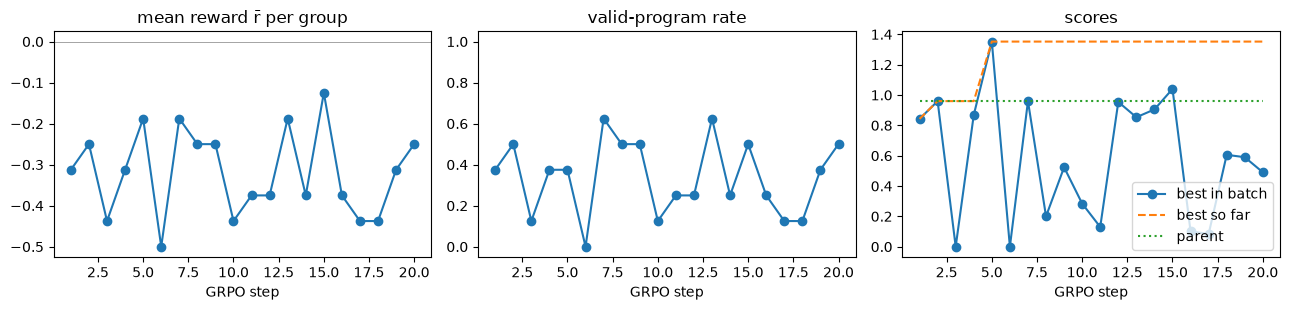

,step,parent_score,reward_mean,valid_rate,improve_rate,best_in_batch,best_so_far,seconds
0,1,0.959764,-0.3125,0.375,0.000,8.425033e-01,0.842503,51.8
1,2,0.959764,-0.2500,0.500,0.000,9.597642e-01,0.959764,110.1
2,3,0.959764,-0.4375,0.125,0.000,4.189970e-15,0.959764,234.0
3,4,0.959764,-0.3125,0.375,0.000,8.683126e-01,0.959764,311.9
4,5,0.959764,-0.1875,0.375,0.125,1.352328e+00,1.352328,388.7
5,6,0.959764,-0.5000,0.000,0.000,0.000000e+00,1.352328,459.9
6,7,0.959764,-0.1875,0.625,0.000,9.597642e-01,1.352328,538.2
7,8,0.959764,-0.2500,0.500,0.000,2.000000e-01,1.352328,586.8
8,9,0.959764,-0.2500,0.500,0.000,5.236237e-01,1.352328,634.2
9,10,0.959764,-0.4375,0.125,0.000,2.842827e-01,1.352328,686.0


LoRA adapter saved: True | trainer log entries: 21


In [15]:
metrics = [json.loads(l) for l in (grpo_out / "metrics.jsonl").read_text().splitlines() if l.strip()]
m = df(metrics)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(m["step"], m["reward_mean"], marker="o"); axes[0].axhline(0, color="gray", lw=0.5); axes[0].set(title="mean reward r̄ per group", xlabel="GRPO step")
axes[1].plot(m["step"], m["valid_rate"], marker="o"); axes[1].set(title="valid-program rate", xlabel="GRPO step", ylim=(-0.05, 1.05))
axes[2].plot(m["step"], m["best_in_batch"], marker="o", label="best in batch"); axes[2].plot(m["step"], m["best_so_far"], ls="--", label="best so far"); axes[2].plot(m["step"], m["parent_score"], ls=":", label="parent"); axes[2].set(title="scores", xlabel="GRPO step"); axes[2].legend()
plt.tight_layout(); plt.show()
display(m[["step", "parent_score", "reward_mean", "valid_rate", "improve_rate", "best_in_batch", "best_so_far", "seconds"]])
print("LoRA adapter saved:", (grpo_out / "adapter").exists(), "| trainer log entries:", len(json.loads((grpo_out / "train_log.json").read_text())))

## 8 · Training vs inference-only (Sec. 4.3 / Fig. 3a, in miniature)

The paper's control compares the *average best-of-k output score per batch* with and without GRPO updates at matched LLM evaluations. Below: the frozen API model's per-iteration average (from §6) next to the small local model's per-step average (from §7). **This is not compute-matched and the two models differ**, so read it only as "does the training curve trend upward while the frozen one stays flat", which is the paper's qualitative claim.

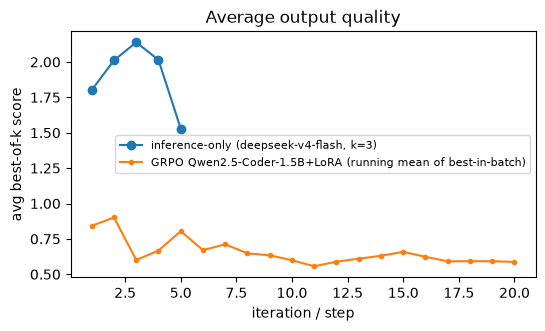

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(range(1, len(logs) + 1), [l.avg_best_of_k for l in logs], marker="o", label=f"inference-only ({common.env()['model'].split('/')[-1]}, k={cfg['k']})")
ax.plot(m["step"], m["best_in_batch"].expanding().mean(), marker=".", label="GRPO Qwen2.5-Coder-1.5B+LoRA (running mean of best-in-batch)")
ax.set(xlabel="iteration / step", ylabel="avg best-of-k score", title="Average output quality"); ax.legend(fontsize=8); plt.show()

## Summary

| Block | Result of this run |
|---|---|
| Evaluator | seed p₀ scores ≈0.96; invalid programs score 0 with a diagnostic (fail-closed) |
| Pool | uniform sampling, valid-only insertion and threshold eviction behave as in Alg. 1 |
| Reward / advantages | eq. (1) and group normalisation reproduce; all-equal groups give zero signal |
| β / τ_t / R / s̄ | schedule and rolling buffer reproduce Alg. 1 lines 4, 17–24 |
| MultiStepRefine | the frozen model improves the seed within a few steps using App. D feedback |
| KTPO search | best score and pool size over iterations (see §6 plots) |
| GRPO | real LoRA training with the improvement reward ran end to end (see §7 plots) |

In [17]:
print(USAGE.summary())

64 requests, 257148 in / 127323 out tokens, 2015s in model calls, $0.0378; by tag: {'refine': 4, 'refine_t1': 12, 'refine_t2': 12, 'refine_t3': 12, 'refine_t4': 12, 'refine_t5': 12}
